Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
from matplotlib.colors import BoundaryNorm


# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application
['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/m

## Reading in global data

In [4]:
# Defining test parameters

# defining modes used
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# getting full (nmax=15) unperturbed records and synthetic suite info
record_dict_global, syn_suite_info_global = Record_Dict_Construct(mode_numbers=mode_numbers, nmax=15)



# defining notebook global colours for each mode in plotting
for i, mode_key in enumerate(syn_suite_info_global):
    syn_suite_info_global[mode_key]["colour"] = tol_muted[i % len(tol_muted)]
    

In [5]:
# for each wave in base set:
# get:
#   power of signal across record
#   period
#   degree of maximum power

degree_list = np.arange(1, 16, 1)


power_dict = {}


spline_path = Path(FELIX_DIR) / "R_splines_arbitrary.h5"

# with spline file accessible
with h5py.File(spline_path, "r") as h5_file:

    # defining notebook global colours for each mode in plotting
    for i, mode_key in enumerate(syn_suite_info_global):

        power_dict[mode_key] = {}

        gnm_resolved = syn_suite_info_global[mode_key]["gnm_resolved"]

        for nmax in degree_list:

            gnm_resolved_nmax = Truncate_Gauss_Coeffs(gnm_resolved, tmax=nmax)

            nmax_key = str(nmax)

            # evaluate power
            power = Total_Power_Over_Record(gnm_resolved_nmax, nmax=nmax)

            power_dict[mode_key][nmax_key] = power

ye
ye
ye
ye
ye
ye
ye


(5.0, 15.0)

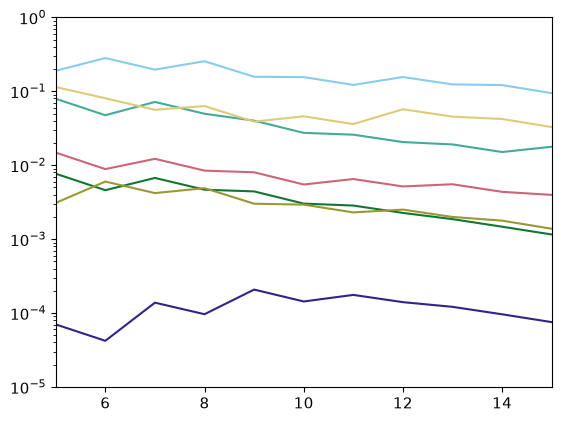

In [7]:
gnm_chaos = CHAOS_Full_SV_Record_Obtain()

chaos_powers = []
for nmax in degree_list:
    gnm_chaos_nmax = Truncate_Gauss_Coeffs(gnm_chaos, tmax=nmax)
    power_chaos = Total_Power_Over_Record(gnm_chaos_nmax, nmax=nmax)
    chaos_powers.append(power_chaos)

for i, mode_key in enumerate(syn_suite_info_global):
    print("ye")
    mode_powers = np.array(list(power_dict[mode_key].values()))

    mode_power_ratio = [mode_powers[n-1]/chaos_powers[n-1] for n in degree_list]

    plt.semilogy(degree_list, mode_power_ratio, color = syn_suite_info_global[mode_key]["colour"])


plt.ylim(bottom=1e-5, top=1e0)
plt.xlim(left=5, right=15)


ye
ye
ye
ye
ye
ye
ye


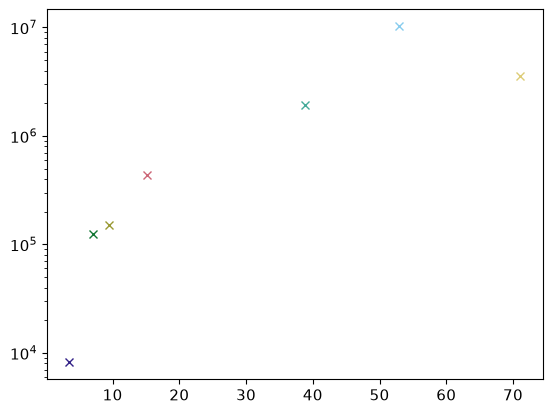

In [38]:
gnm_chaos = CHAOS_Full_SV_Record_Obtain()

chaos_powers = []
for nmax in degree_list:
    gnm_chaos_nmax = Truncate_Gauss_Coeffs(gnm_chaos, tmax=nmax)
    power_chaos = Total_Power_Over_Record(gnm_chaos_nmax, nmax=nmax)
    chaos_powers.append(power_chaos)

for i, mode_key in enumerate(syn_suite_info_global):
    print("ye")
    mode_powers = np.array(list(power_dict[mode_key].values()))

    mode_power = mode_powers[-1]
    mode_period = syn_suite_info_global[mode_key]["true_period"]

    plt.semilogy(mode_period, mode_power, color = syn_suite_info_global[mode_key]["colour"], marker="x")